# Implement Flow Matching from Scratch

**Difficulty**: 🔴 Hard

**Companies**: Meta, Stability AI, Black Forest Labs, Google

---

### Problem Statement

Flow Matching trains a network to predict the **velocity field** of a probability path that transports a simple noise distribution to the data distribution. Unlike DDPM, there is no variance schedule: the forward path is a straight-line interpolation between noise and data, and sampling is done by integrating an ODE.

Your task is to implement the complete flow matching pipeline: the interpolation path, a velocity-prediction network, the training objective, and an ODE sampling loop. You will train on the same 2D concentric-circles distribution that DDPM struggled with — your samples should recover the two rings, including the empty gap between them.

---

### Requirements

1. **Interpolation Path** — Given clean data `x_0`, Gaussian noise `x_1`, and a time `t ~ Uniform(0, 1)`, compute `x_t = (1 - t) * x_0 + t * x_1`.
2. **Velocity Network** — A simple MLP that takes `(x_t, t)` and predicts the velocity `v = x_1 - x_0`. You can reuse the sinusoidal timestep embedding and MLP architecture from the DDPM exercise.
3. **Training** — Minimize MSE between predicted velocity and target velocity `x_1 - x_0`.
4. **ODE Sampling** — Start from pure noise at `t = 1` and integrate `dx/dt = v(x, t)` down to `t = 0` with an Euler loop (~50 steps).

---

### Constraints

- ✅ Use PyTorch for all implementations.
- ✅ The velocity network can be a simple MLP (no need for a full UNet) since we work with 2D point data.
- ✅ Train on synthetic 2D data (concentric circles from scikit-learn).
- ❌ Do **not** use any pre-built diffusion/flow libraries.

---

<details>
  <summary>💡 Hint</summary>

  - The target velocity is constant along each straight path: `v = x_1 - x_0` does not depend on `t`.
  - Sample `t` per-example as floats in `[0, 1)` and remember to reshape it to `(B, 1)` for broadcasting against `x`.
  - Euler integration: `x = x + v(x, t) * dt` with `dt = -1 / n_steps`, stepping `t` from 1 down to 0.
  - The sinusoidal timestep embedding from DDPM expects integer-like inputs; scale `t` (e.g. `t * 1000`) before embedding, or it will carry almost no signal.

</details>

---

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

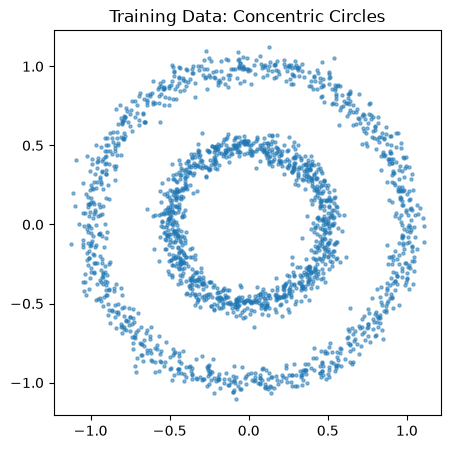

Data shape: torch.Size([2000, 2])


In [65]:
# Generate training data: concentric circles
torch.manual_seed(42)
np.random.seed(42)

n_samples = 2000
data, _ = make_circles(n_samples=n_samples, noise=0.05, factor=0.5)
data = torch.tensor(data, dtype=torch.float32)

# Visualize
plt.figure(figsize=(5, 5))
plt.scatter(data[:, 0].numpy(), data[:, 1].numpy(), s=5, alpha=0.5)
plt.title('Training Data: Concentric Circles')
plt.axis('equal')
plt.show()

print(f'Data shape: {data.shape}')

---

### Your implementation

Implement the interpolation path, velocity network, training loop, and ODE sampler below. When you're done, store your generated points in a variable named `samples` (a tensor of shape `(1000, 2)`) and run the validation cell.

In [66]:
# --- Part 2: Velocity Network ---

class SinusoidalPositionEmbeddings(nn.Module):
    """Sinusoidal embeddings for timestep encoding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


class MLP(nn.Module):
    """MLP that takes (x_t, t) and predicts the velocity v = x_1 - x_0."""
    def __init__(self, data_dim=2, hidden_dim=128, time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
        )
        self.input_proj = nn.Linear(data_dim, hidden_dim)
        self.time_proj = nn.Linear(time_dim, hidden_dim)
        self.net = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU()
            ) for _ in range(6)
        ])
        self.output_proj = nn.Linear(hidden_dim, data_dim)

    def forward(self, x, t):
        # t arrives in [0, 1); scale up so the sinusoidal embedding carries signal
        t = t.reshape(-1) * 1000
        time = self.time_proj(self.time_mlp(t))
        x = self.input_proj(x)
        x = time + x
        for layer in self.net:
            x = x + layer(x)
        return self.output_proj(x)


Step 1000/5000, Loss: 0.883021
Step 2000/5000, Loss: 0.865008
Step 3000/5000, Loss: 0.857844
Step 4000/5000, Loss: 0.852296
Step 5000/5000, Loss: 0.844546


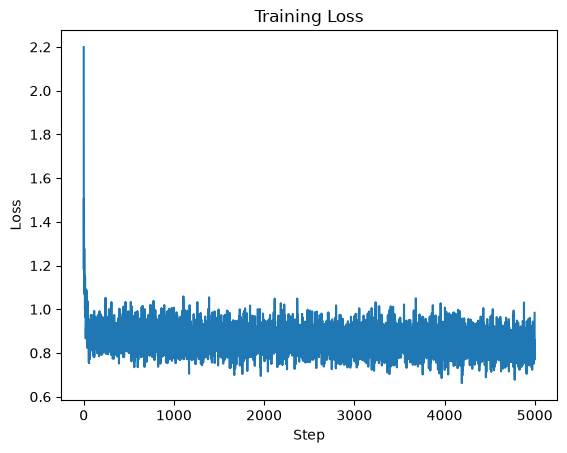

In [67]:
# --- Part 3: Training Loop ---
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_steps = 5000
batch_size = 256
losses = []

model.train()
for i in range(n_steps):
    # Sample a batch of data points, noise vectors, and times
    idx = torch.randint(0, n_samples, (batch_size,))
    x_0 = data[idx]
    x_1 = torch.randn_like(x_0)
    t = torch.rand(batch_size, 1)

    # Interpolate along the straight path; the model sees x_t, not the noise
    x_t = (1 - t) * x_0 + t * x_1
    target = x_0 - x_1
    pred = model(x_t, t)
    loss = F.mse_loss(pred, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.detach())
    if (i + 1) % 1000 == 0:
        print(f'Step {i+1}/{n_steps}, Loss: {sum(losses[-1000:]) / 1000:.6f}')

plt.plot(losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


In [68]:
# --- Part 4: ODE Sampling ---

# Start from x ~ N(0, I) at t = 1, Euler-integrate dx/dt = v(x, t) down to t = 0
model.eval()
with torch.no_grad():
    n_step = 8
    dt = 1 / float(n_step)
    samples = torch.randn(1000, 2)
    for i in range(n_step):
        t = torch.full((1000, 1), 1 - dt * (i + 1))
        pred = model(samples, t)
        samples = samples + pred * dt

print(f'Generated samples shape: {samples.shape}')

Generated samples shape: torch.Size([1000, 2])


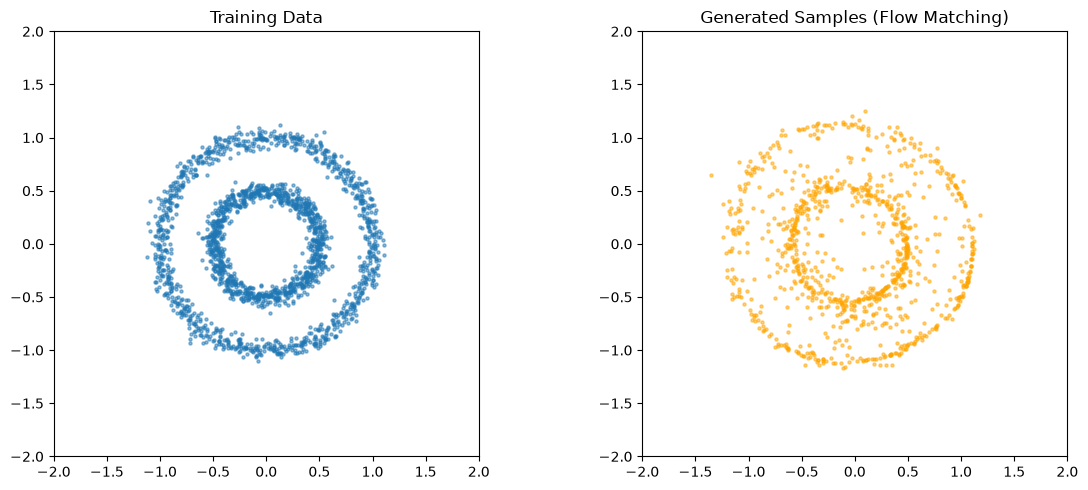

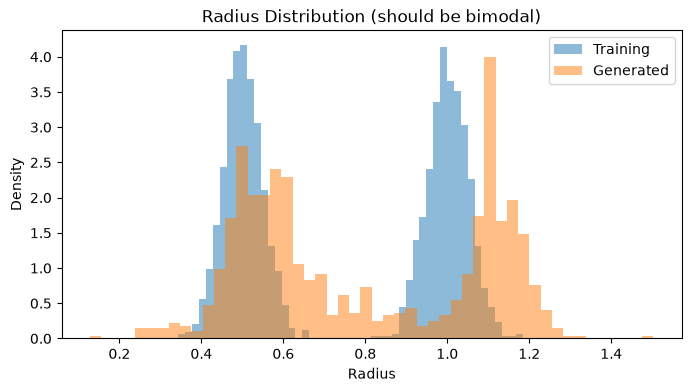

=== Validation ===
PASSED: Generated samples in reasonable range
Gap fraction - Training: 0.021, Generated: 0.212
PASSED: Ring structure recovered (few samples in the gap)
Inner ring fraction - Generated: 0.378 (expected ~0.5)
PASSED: Both rings populated

All validations passed!


In [69]:
# --- Validation ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(data[:, 0].numpy(), data[:, 1].numpy(), s=5, alpha=0.5)
axes[0].set_title('Training Data')
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-2, 2)
axes[0].set_aspect('equal')

axes[1].scatter(samples[:, 0].numpy(), samples[:, 1].numpy(), s=5, alpha=0.5, c='orange')
axes[1].set_title('Generated Samples (Flow Matching)')
axes[1].set_xlim(-2, 2)
axes[1].set_ylim(-2, 2)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

# Radius histograms: the rings should show up as two modes with a gap
plt.figure(figsize=(8, 4))
plt.hist(data.norm(dim=1).numpy(), bins=50, alpha=0.5, label='Training', density=True)
plt.hist(samples.norm(dim=1).numpy(), bins=50, alpha=0.5, label='Generated', density=True)
plt.xlabel('Radius')
plt.ylabel('Density')
plt.legend()
plt.title('Radius Distribution (should be bimodal)')
plt.show()

print('=== Validation ===')

# Check generated samples are in reasonable range
assert samples.abs().max() < 10, 'Generated samples have extreme values!'
print('PASSED: Generated samples in reasonable range')

# Check the ring structure was learned: the two rings live at radii ~0.5 and ~1.0,
# so the fraction of samples in the gap (0.6 < r < 0.9) should be low.
train_radii = data.norm(dim=1)
gen_radii = samples.norm(dim=1)
train_gap_frac = ((train_radii > 0.6) & (train_radii < 0.9)).float().mean().item()
gen_gap_frac = ((gen_radii > 0.6) & (gen_radii < 0.9)).float().mean().item()
print(f'Gap fraction - Training: {train_gap_frac:.3f}, Generated: {gen_gap_frac:.3f}')
assert gen_gap_frac < 0.25, 'Too many samples in the gap between rings — the ring structure was not learned!'
print('PASSED: Ring structure recovered (few samples in the gap)')

# Check both rings are populated
inner_frac = (gen_radii < 0.6).float().mean().item()
print(f'Inner ring fraction - Generated: {inner_frac:.3f} (expected ~0.5)')
assert 0.2 < inner_frac < 0.8, 'One of the rings is missing or collapsed!'
print('PASSED: Both rings populated')

print('\nAll validations passed!')